<a href="https://colab.research.google.com/github/seigdev/artificial-intelligence/blob/main/assessments/assignment_one.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install nltk

In [57]:
import pandas as pd
import numpy as np
import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt
import gensim
import re
import tldextract
import seaborn as sns
from collections import Counter
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.layers import Embedding, LSTM, Dense, Input, Concatenate

## data collection

In [ ]:
# load remote dataset
try:
    datasets_raw = "https://raw.githubusercontent.com/seigdev/artificial-intelligence/refs/heads/main/crypto_data.json"
    datasets_df = pd.read_json(datasets_raw)
    print("✅ Data loaded successfully!")
except Exception as e:
    print(f"🚩 Error loading data: {e}")

## EDA

In [ ]:
# Class Distribution Analysis
print("\n=== Class Distribution ===")
class_distribution = datasets_df["label_no"].value_counts()
print(class_distribution)

In [ ]:
# Plot with annotations
plt.figure(figsize=(8, 4))
ax = sns.barplot(x=class_distribution.index, y=class_distribution.values, palette=["green", "red"])
plt.title(f"Class Distribution (Scams: {class_distribution[1]} | Legit: {class_distribution[0]})", fontsize=12)
plt.xlabel("Label (0: Legitimate, 1: Scam)")
plt.ylabel("Count")

In [ ]:
print("=== URL Length Analysis ===")
datasets_df["url_length"] = datasets_df["url"].apply(len)
datasets_df["url_length"]

In [ ]:
# Compare scam vs legit URL lengths
plt.figure(figsize=(10, 5))
sns.boxplot(x="label_no", y="url_length", data=datasets_df, palette=["green", "red"])
plt.title("URL Length Distribution by Class", fontsize=12)
plt.xlabel("Label (0: Legitimate, 1: Scam)")
plt.ylabel("URL Length (chars)")
plt.show()

In [ ]:
print("=== Top 10 Scam Domains ===")
datasets_df["domain"] = datasets_df["url"].apply(lambda x: tldextract.extract(x).domain)
scam_domains = datasets_df[datasets_df["label_no"] == 1]["domain"].value_counts().head(10)
print(scam_domains)

In [ ]:
# Plot top scam domains
plt.figure(figsize=(10, 5))
sns.barplot(x=scam_domains.values, y=scam_domains.index, palette="Reds_d")
plt.title("Top 10 Domains in Scam URLs", fontsize=12)
plt.xlabel("Count")
plt.ylabel("Domain")
plt.show()

In [ ]:
# Extract keywords from scam URLs
scam_urls = datasets_df[datasets_df["label_no"] == 1]["url"].tolist()
keywords = []

# List of common terms to exclude 
exempted_terms = {'https', 'http', 'www', 'com', 'net', 'org', 'io', 'info'}

for url in scam_urls:
    tokens = re.split(r'[/?=&.:-]', url.lower())
    keywords.extend([t for t in tokens if len(t) > 3 and (t not in exempted_terms)])

top_keywords = Counter(keywords).most_common(10)
print("=== Top 10 Keywords in Scams ===")
print(top_keywords)

## preprocessing

In [ ]:
# drop label column since it contains text representation
# and we will use label_no for numerical representation
datasets_df.drop(columns=["label"], inplace=True)

# rename label_no to label for consistency
datasets_df.rename(columns={"label_no": "label"}, inplace=True)

In [ ]:
def clean_url(url):

    # Convert to lowercase and remove protocol
    url = re.sub(r'https?://(www\.)?', '', url.lower())
    
    # Replace homoglyphs (e.g., í -> i)
    homoglyphs = {
        'í': 'i', 'é': 'e', 'á': 'a', 'à': 'a', 'ã': 'a', 'ó': 'o', 
        'ü': 'u', 'ñ': 'n', 'ç': 'c', ' ': '-', '_': '-'
    }
    for glyph, replacement in homoglyphs.items():
        url = url.replace(glyph, replacement)
    
    # Remove TLDs (but keep the dot structure)
    url = re.sub(r'(\.[a-z]{2,3}){1,2}(?=\/|$)', '', url)
    
    # Tokenize by splitting on special chars
    tokens = re.split(r'[/?=&.,-]', url)
    tokens = [token for token in tokens if token and len(token) > 1]  # Drop single chars
    
    return " ".join(tokens)

# Apply cleaning to DataFrame
datasets_df['cleaned_url'] = datasets_df['url'].apply(clean_url)

In [ ]:
datasets_df.head()

## feature engineering

In [ ]:
# Feature Extraction Function
def extract_features(url):
    features = {}
    
    # Basic features
    features['url_length'] = len(url)
    features['num_digits'] = sum(c.isdigit() for c in url)
    features['num_special_chars'] = len(re.findall(r'[^a-zA-Z0-9]', url))
    features['num_subdomains'] = url.count('.')
    features['has_https'] = 1 if 'https' in url else 0
    
    # Scam-specific keywords (expanded list)
    scam_keywords = ["free", "bonus", "earn", "crypto", "win", "wallet", 
                     "verify", "airdrop", "claim", "reward", "login"]
    features['suspicious_keywords'] = sum(kw in url for kw in scam_keywords)
    
    # Entropy (randomness detection)
    from collections import Counter
    prob = [freq / len(url) for freq in Counter(url).values()]
    features['entropy'] = -sum(p * np.log2(p) for p in prob if p > 0)
    
    # Simulate domain age (0 = new, 1 = old) using substring checks
    features['is_new_domain'] = 1 if any(kw in url for kw in ["verify", "support", "update"]) else 0
    
    # Homoglyph detection (e.g., "bǐnance")
    features['has_homoglyphs'] = 1 if re.search(r'[^a-z0-9.-]', url) else 0
    
    return features

# Apply feature extraction
df_features = datasets_df['url'].apply(lambda x: pd.Series(extract_features(x)))

In [ ]:
map = {0: "legit", 1: "scam"}
map

#### word2Vec

In [41]:
# Train custom Word2Vec model
sentences = [word_tokenize(url) for url in datasets_df['cleaned_url'].tolist()]

# Initialize and build vocabulary in one step
word2vec_model = gensim.models.Word2Vec(
    sentences=sentences,  # This builds the vocabulary automatically
    vector_size=300,
    window=5,
    min_count=1,
    workers=4
)

# train the model
word2vec_model.train(
    sentences,
    total_examples=word2vec_model.corpus_count,
    epochs=10
)

def url_to_vector(url):
    tokens = word_tokenize(url)
    vectors = [word2vec_model.wv[token] for token in tokens if token in word2vec_model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(300)


# Apply to all URLs
X_word2vec = np.array([url_to_vector(url) for url in datasets_df['cleaned_url']])

X_word2vec

array([[ 1.16944313e-03, -2.03682180e-03,  3.67836154e-04, ...,
         2.58445949e-03, -1.81382336e-03,  2.72218231e-03],
       [ 6.77193627e-02,  2.16718480e-01, -1.07767098e-02, ...,
        -1.90408770e-02,  1.78148717e-01, -2.41588145e-01],
       [ 4.16572113e-03,  2.97334138e-02, -7.43538490e-04, ...,
        -9.63072479e-03,  1.83589496e-02, -3.07262670e-02],
       ...,
       [ 1.56600833e-01,  8.32777619e-02,  3.39249261e-02, ...,
        -1.57833695e-02,  5.68718374e-01, -3.58132988e-01],
       [-7.88136851e-04,  1.33000270e-01, -3.62659968e-03, ...,
        -1.42089114e-01,  4.63971138e-01, -3.33199561e-01],
       [ 4.32134941e-02,  3.76069397e-01, -6.85406625e-02, ...,
        -5.52993193e-02,  1.25848338e-01, -3.08995068e-01]])

#### nnlm-50

In [26]:
# load NNLM embeddings (50-dimensional)
embed_50 = hub.load("https://tfhub.dev/google/nnlm-en-dim50/2")

# fetch embeddings of urls
X_embeddings_50 = embed_50(datasets_df["cleaned_url"].tolist()).numpy()

X_embeddings_50

2025-04-08 13:45:33.986213: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'sentences' with dtype string and shape [?]
	 [[{{node sentences}}]]


array([[ 0.37831855,  0.02606503, -0.09907459, ...,  0.14267674,
        -0.30755177,  0.12636171],
       [ 0.18235798,  0.007694  , -0.12998186, ...,  0.04249313,
         0.18891454, -0.19477235],
       [ 0.41060403, -0.15526298, -0.10885525, ...,  0.15256283,
         0.03047267,  0.10180621],
       ...,
       [ 0.15045999, -0.21153322,  0.12674113, ...,  0.13879257,
         0.2111132 ,  0.11634694],
       [ 0.34883028, -0.19791578, -0.03702366, ...,  0.01202757,
        -0.00872015,  0.10776448],
       [ 0.12208395, -0.12377994, -0.14059715, ...,  0.17117925,
         0.20474009,  0.1928035 ]], dtype=float32)

#### nnlm-128

In [ ]:
# using nnlm-128

# load NNLM embeddings (128-dimensional)
embed_128 = hub.load("https://tfhub.dev/google/nnlm-en-dim128/2")

# fetch embeddings of urls
X_embeddings_128 = embed_128(datasets_df["cleaned_url"].tolist()).numpy()

X_embeddings_128

2025-04-08 13:45:36.795584: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'sentences' with dtype string and shape [?]
	 [[{{node sentences}}]]


array([[ 0.37831855,  0.02606503, -0.09907459, ...,  0.14267674,
        -0.30755177,  0.12636171],
       [ 0.18235798,  0.007694  , -0.12998186, ...,  0.04249313,
         0.18891454, -0.19477235],
       [ 0.41060403, -0.15526298, -0.10885525, ...,  0.15256283,
         0.03047267,  0.10180621],
       ...,
       [ 0.15045999, -0.21153322,  0.12674113, ...,  0.13879257,
         0.2111132 ,  0.11634694],
       [ 0.34883028, -0.19791578, -0.03702366, ...,  0.01202757,
        -0.00872015,  0.10776448],
       [ 0.12208395, -0.12377994, -0.14059715, ...,  0.17117925,
         0.20474009,  0.1928035 ]], dtype=float32)

#### prepare for training

In [ ]:
# prepare data for LSTM training
# Tokenize the cleaned URLs
tokenizer = Tokenizer()
tokenizer.fit_on_texts(datasets_df['cleaned_url']) 
sequences = tokenizer.texts_to_sequences(datasets_df['cleaned_url']) 

# Pad the sequences to ensure uniform length
max_sequence_length = 50  # You can adjust this value based on your dataset
X_sequences = pad_sequences(sequences, maxlen=max_sequence_length, padding='post')

In [52]:
# combine text features (cleaned_url) and engineered features
X_combined = np.hstack([X_embeddings_50, df_features.values])

# Split the data while maintaining alignment between text and engineered features
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, datasets_df['label'], test_size=0.2, random_state=42)

## modelling

#### logistics regression

/Users/sooreoluwa/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.9161475409836065
              precision    recall  f1-score   support

           0       0.85      0.64      0.73      2184
           1       0.93      0.98      0.95     10016

    accuracy                           0.92     12200
   macro avg       0.89      0.81      0.84     12200
weighted avg       0.91      0.92      0.91     12200



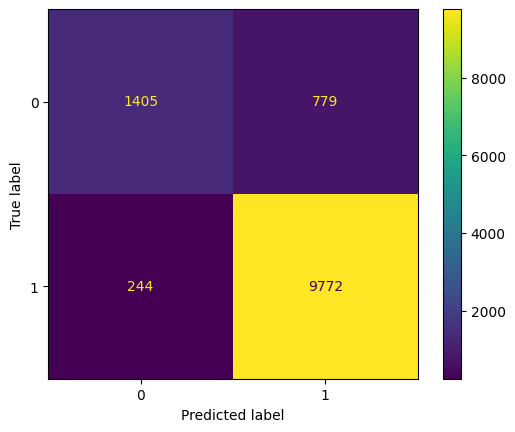

In [31]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)
confusion = confusion_matrix(y_test, lr_preds)
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_preds))
print(classification_report(y_test, lr_preds))  
disp = ConfusionMatrixDisplay(confusion, display_labels = map.keys())
disp.plot()
plt.show()

#### LSTM

In [53]:
# input for sequential data
input_seq = Input(shape=(X_sequences.shape[1],))
vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 300

# Fill the embedding matrix with Word2Vec embeddings
embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in tokenizer.word_index.items():
    if word in word2vec_model.wv:
        embedding_matrix[i] = word2vec_model.wv[word]

embedding_layer = Embedding(input_dim=vocab_size, 
    output_dim=300, 
    weights=[embedding_matrix], 
    input_length=X_sequences.shape[1], 
    trainable=True
)(input_seq)

lstm_out = LSTM(64, return_sequences=True)(embedding_layer)
lstm_out = LSTM(32)(lstm_out)

# input for additional features
input_features = Input(shape=(df_features.shape[1],))

# combine LSTM output with additional features
combined = Concatenate()([lstm_out, input_features])

# dense layers for classification
dense_out = Dense(64, activation='relu')(combined)
output = Dense(1, activation='sigmoid')(dense_out)

# define the model
lstm_model = tf.keras.Model(inputs=[input_seq, input_features], outputs=output)

# compile the model
lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

2025-04-08 16:53:27.971335: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-04-08 16:53:27.980241: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-04-08 16:53:27.985868: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

In [54]:
# train the model
lstm_model.fit(
    [X_train[:, :X_sequences.shape[1]], X_train[:, X_sequences.shape[1]:]],
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(
        [X_test[:, :X_sequences.shape[1]], X_test[:, X_sequences.shape[1]:]],
        y_test
    )
)

# evaluate the model
loss, accuracy = lstm_model.evaluate(
    [X_test[:, :X_sequences.shape[1]], X_test[:, X_sequences.shape[1]:]],
    y_test
)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

Epoch 1/5


2025-04-08 16:53:42.869041: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-04-08 16:53:42.874538: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-04-08 16:53:42.877575: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

1525/1525 [==============================] - ETA: 0s - loss: 0.3797 - accuracy: 0.8418

2025-04-08 17:01:32.620463: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-04-08 17:01:32.623106: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-04-08 17:01:32.626081: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

1525/1525 [==============================] - 484s 306ms/step - loss: 0.3797 - accuracy: 0.8418 - val_loss: 0.3687 - val_accuracy: 0.8476
Epoch 2/5
1525/1525 [==============================] - 470s 308ms/step - loss: 0.3583 - accuracy: 0.8554 - val_loss: 0.3442 - val_accuracy: 0.8657
Epoch 3/5
1525/1525 [==============================] - 463s 304ms/step - loss: 0.3490 - accuracy: 0.8597 - val_loss: 0.3358 - val_accuracy: 0.8643
Epoch 4/5
1525/1525 [==============================] - 466s 306ms/step - loss: 0.3411 - accuracy: 0.8628 - val_loss: 0.3339 - val_accuracy: 0.8701
Epoch 5/5
382/382 [==============================] - 13s 33ms/step - loss: 0.3218 - accuracy: 0.8721
Test Loss: 0.3218232989311218
Test Accuracy: 0.8721311688423157
